# Step 1. Data Acquisition (API-based Real-World Dataset)

## 1.1 Overview
* The goal of Step 1 is to obtain a real-world dataset directly from an external online API using Python. The dataset will later be cleaned, analysed, and used for exploratory and inferential analysis.
 To align with the theme Loan Approval & Credit Conditions, I collect three important financial indicators that describe a country’s lending environment, credit risk, and credit supply.

## 1.2 Data Source(World Bank Open Data API)
The dataset is obtained through the official World Bank Indicators API, a publicly available REST API that provides global economic and financial indicators in JSON format.
https://api.worldbank.org/v2/country/{country_code}/indicator/{indicator_code}?format=json&per_page=2000
This API does not require any API key, and returns data directly from the World Bank database.
All data in this step is fetched programmatically using Python’s requests library

## 1.3 Selected Indicators (Loan-Related Variables)

To construct a dataset suitable for analysing loan approval and credit conditions, I selected three key financial indicators from the World Bank Open Data API. These indicators describe the overall lending environment, credit risk, and the availability of credit within an economy.

• Indicator: FR.INR.LEND
Meaning: Lending interest rate (%)
Relevance: Higher lending interest rates typically make loan approval more restrictive. When borrowing costs rise, banks tighten lending standards and fewer applicants meet affordability requirements.

• Indicator: FB.AST.NPER.ZS
Meaning: Non-performing loans (% of total gross loans)
Relevance: This indicator measures credit risk. A higher proportion of non-performing loans signals a riskier loan environment, which directly affects banks’ willingness to approve new loans.

• Indicator: FS.AST.PRVT.GD.ZS
Meaning: Domestic credit to the private sector (% of GDP)
Relevance: This reflects the level of credit supply in the economy. When credit to the private sector is high, banks are actively issuing loans, making it an important factor associated with loan availability and approval practices.

Together, these variables capture loan availability, lending conditions, and credit risk, which are fundamental drivers of loan approval behaviour across countries and over time.

## 1.4 Countries Included
To ensure the dataset exceeds the required 150 rows, I collect annual data for 7 major economies:

United States (US)

Canada (CA)

United Kingdom (GB)

Germany (DE)

France (FR)

Japan (JP)

Australia (AU)

Each country typically contains 50–60 years of observations.

## 1.5 Data Extraction Method
For each indicator:
1. Construct the API URL
2. Use `requests.get()` to retrieve JSON data
3. Parse the response into a pandas DataFrame
4. Repeat for all selected countries
5. Merge all indicators on (`country_code`, `year`)
6. Save the combined dataset as:
```loan_worldbank_dataset.csv```

## 1.6. Variables in the Final Dataset

The final dataset contains the following variables:

| Column Name               | Description                                      |
|---------------------------|--------------------------------------------------|
| `country_code`            | ISO country code                                 |
| `country_name`            | Country name                                     |
| `year`                    | Observation year                                 |
| `lending_interest_rate`   | Lending interest rate (%)                        |
| `nonperforming_loan_ratio`| Non-performing loans (%)                         |
| `credit_to_private_gdp`   | Credit to private sector (% of GDP)             |

## 1.7 Code: Fetch Data from the World Bank API

In [22]:
import requests
import pandas as pd


# Indicators we want to collect
INDICATORS = {
    "FR.INR.LEND": "lending_interest_rate",       # 贷款利率 (%)
    "FB.AST.NPER.ZS": "nonperforming_loan_ratio", # 不良贷款率 (%)
    "FS.AST.PRVT.GD.ZS": "credit_to_private_gdp", # 对私营部门信贷 / GDP (%)
}

# Countries included in the dataset
COUNTRIES = {
    "US": "United States",
    "CA": "Canada",
    "GB": "United Kingdom",
    "DE": "Germany",
    "FR": "France",
    "JP": "Japan",
    "AU": "Australia",
}


def fetch_indicator_for_countries(indicator_code: str) -> pd.DataFrame:
    """
    Fetch one World Bank indicator for all selected countries.
    """
    rows = []

    for country_code, country_name in COUNTRIES.items():
        url = (
            f"https://api.worldbank.org/v2/country/{country_code}"
            f"/indicator/{indicator_code}?format=json&per_page=2000"
        )
        print(f"Fetching {indicator_code} for {country_code} ...")

        r = requests.get(url)
        r.raise_for_status()
        data = r.json()

        # data = [metadata, series]
        if len(data) < 2:
            continue

        observations = data[1]

        for obs in observations:
            rows.append({
                "country_code": country_code,
                "country_name": country_name,
                "year": int(obs["date"]),
                indicator_code: pd.to_numeric(obs["value"], errors="coerce")
            })

    return pd.DataFrame(rows)


def build_loan_dataset() -> pd.DataFrame:
    """
    Fetch all indicators and merge them into one dataset.
    """
    df_list = []

    for indicator in INDICATORS.keys():
        df_ind = fetch_indicator_for_countries(indicator)
        df_list.append(df_ind)

    # merge all indicators on (country_code, year)
    df_merged = df_list[0]

    for df in df_list[1:]:
        df_merged = df_merged.merge(df, on=["country_code", "country_name", "year"], how="outer")

    # rename coded indicator names to readable labels
    df_merged = df_merged.rename(columns=INDICATORS)

    # sorted by country then year
    return df_merged.sort_values(["country_code", "year"])


# Build dataset
df = build_loan_dataset()

# Display results
print("Dataset shape:", df.shape)
df.head()

Fetching FR.INR.LEND for US ...
Fetching FR.INR.LEND for CA ...
Fetching FR.INR.LEND for GB ...
Fetching FR.INR.LEND for DE ...
Fetching FR.INR.LEND for FR ...
Fetching FR.INR.LEND for JP ...
Fetching FR.INR.LEND for AU ...
Fetching FB.AST.NPER.ZS for US ...
Fetching FB.AST.NPER.ZS for CA ...
Fetching FB.AST.NPER.ZS for GB ...
Fetching FB.AST.NPER.ZS for DE ...
Fetching FB.AST.NPER.ZS for FR ...
Fetching FB.AST.NPER.ZS for JP ...
Fetching FB.AST.NPER.ZS for AU ...
Fetching FS.AST.PRVT.GD.ZS for US ...
Fetching FS.AST.PRVT.GD.ZS for CA ...
Fetching FS.AST.PRVT.GD.ZS for GB ...
Fetching FS.AST.PRVT.GD.ZS for DE ...
Fetching FS.AST.PRVT.GD.ZS for FR ...
Fetching FS.AST.PRVT.GD.ZS for JP ...
Fetching FS.AST.PRVT.GD.ZS for AU ...
Dataset shape: (455, 6)


,country_code,country_name,year,lending_interest_rate,nonperforming_loan_ratio,credit_to_private_gdp
0,AU,Australia,1960,5.000000,NaN,19.115204
1,AU,Australia,1961,5.500000,NaN,17.628450
2,AU,Australia,1962,5.500000,NaN,18.646354
3,AU,Australia,1963,5.125000,NaN,19.282483
4,AU,Australia,1964,5.072917,NaN,20.111524


In [23]:
df.to_csv("loan_worldbank_dataset.csv", index=False, encoding="utf-8-sig")
print("Saved as loan_worldbank_dataset.csv")

Saved as loan_worldbank_dataset.csv


# Step 2. Perform data preparation and cleaning

## Step 2.1 – Load the dataset

In [24]:
import pandas as pd
import numpy as np

df = pd.read_csv("loan_worldbank_dataset.csv")
df.head()

,country_code,country_name,year,lending_interest_rate,nonperforming_loan_ratio,credit_to_private_gdp
0,AU,Australia,1960,5.000000,NaN,19.115204
1,AU,Australia,1961,5.500000,NaN,17.628450
2,AU,Australia,1962,5.500000,NaN,18.646354
3,AU,Australia,1963,5.125000,NaN,19.282483
4,AU,Australia,1964,5.072917,NaN,20.111524


## Step 2.2 – Inspect structure and missing values

In [33]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country_code              455 non-null    object 
 1   country_name              455 non-null    object 
 2   year                      455 non-null    int64  
 3   lending_interest_rate     253 non-null    float64
 4   nonperforming_loan_ratio  100 non-null    float64
 5   credit_to_private_gdp     346 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 21.5+ KB


country_code                  0
country_name                  0
year                          0
lending_interest_rate       202
nonperforming_loan_ratio    355
credit_to_private_gdp       109
dtype: int64

## Step 2.3 – Basic cleaning

### 2.3.1. Convert numeric columns to numeric types

In [34]:
df_clean = df.copy()

numeric_cols = [
    "year",
    "lending_interest_rate",
    "nonperforming_loan_ratio",
    "credit_to_private_gdp"
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country_code              455 non-null    object 
 1   country_name              455 non-null    object 
 2   year                      455 non-null    int64  
 3   lending_interest_rate     253 non-null    float64
 4   nonperforming_loan_ratio  100 non-null    float64
 5   credit_to_private_gdp     346 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 21.5+ KB


### 2.3.2. Remove very early years with massive missing data

In [35]:
df_clean = df_clean[df_clean["year"] >= 1980]

### 2.3.3. Drop rows missing key indicators

In [36]:
df_clean = df_clean.dropna(subset=["lending_interest_rate", "nonperforming_loan_ratio"])

### 2.3.4. Impute credit_to_private_gdp missing values

In [37]:
df_clean["credit_to_private_gdp"] = df_clean.groupby("country_code")[
    "credit_to_private_gdp"
].transform(lambda x: x.fillna(x.median()))

## Step 2.4 – Create new engineered features

### 2.4.1. Create decade (e.g., 1980 → 1980s)

In [38]:
df_clean["decade"] = (df_clean["year"] // 10) * 10

### 2.4.2. Create a risk index
一个简单的“风险强度”特征：贷款利率 × 不良贷款率

In [39]:
df_clean["risk_index"] = (
    df_clean["lending_interest_rate"] * df_clean["nonperforming_loan_ratio"] / 100
)

## Step 2.5 – Check the final cleaned dataset

In [40]:
df_clean.info()
df_clean.isna().sum()
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
Index: 57 entries, 45 to 451
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country_code              57 non-null     object 
 1   country_name              57 non-null     object 
 2   year                      57 non-null     int64  
 3   lending_interest_rate     57 non-null     float64
 4   nonperforming_loan_ratio  57 non-null     float64
 5   credit_to_private_gdp     57 non-null     float64
 6   decade                    57 non-null     int64  
 7   risk_index                57 non-null     float64
dtypes: float64(4), int64(2), object(2)
memory usage: 4.0+ KB


,country_code,country_name,year,lending_interest_rate,nonperforming_loan_ratio,credit_to_private_gdp,decade,risk_index
45,AU,Australia,2005,7.258333,0.564453,108.433078,2000,0.040970
46,AU,Australia,2006,7.612500,0.574013,113.601510,2000,0.043697
47,AU,Australia,2007,8.195833,0.559226,120.511803,2000,0.045833
48,AU,Australia,2008,8.908333,1.355262,121.713420,2000,0.120731
49,AU,Australia,2009,6.020833,2.018065,122.507455,2000,0.121504


# Step 3. Exploratory Data Analysis (EDA)

## 3.1 Descriptive Statistics

In [41]:
df_clean[[
    "lending_interest_rate",
    "nonperforming_loan_ratio",
    "credit_to_private_gdp",
    "risk_index"
]].describe()

,lending_interest_rate,nonperforming_loan_ratio,credit_to_private_gdp,risk_index
count,57.000000,57.000000,57.000000,57.000000
mean,3.771695,1.623277,151.161223,0.050403
std,2.234989,1.138676,29.213584,0.040689
min,0.500000,0.420326,108.433078,0.008272
25%,2.395833,0.844689,123.815710,0.021292
50%,3.250000,1.266871,142.663702,0.039263
75%,5.282500,2.129090,175.443844,0.051372
max,8.908333,4.959904,220.381317,0.161197


## 3.2 Histograms – Distribution of Key Variables

### 3.2.1 Lending interest rate distribution

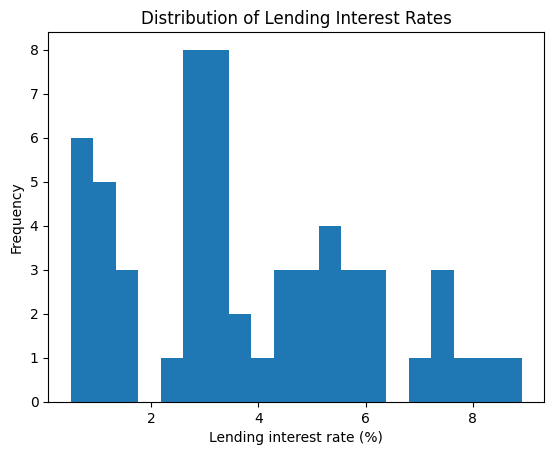

In [42]:
import matplotlib.pyplot as plt

plt.hist(df_clean["lending_interest_rate"].dropna(), bins=20)
plt.xlabel("Lending interest rate (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Lending Interest Rates")
plt.show()

### 3.2.2 Non-performing loan ratio distribution

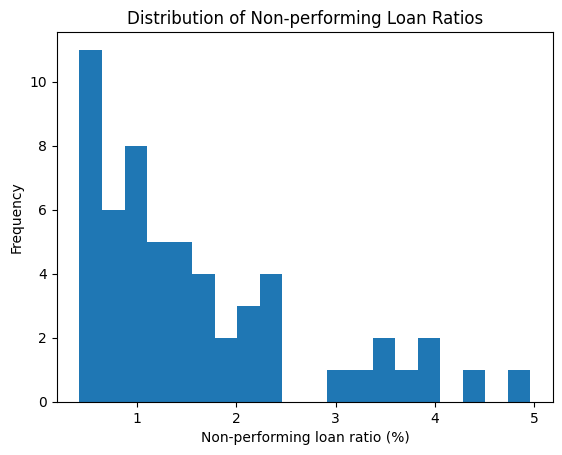

In [43]:
plt.hist(df_clean["nonperforming_loan_ratio"].dropna(), bins=20)
plt.xlabel("Non-performing loan ratio (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Non-performing Loan Ratios")
plt.show()

### 3.2.3 Credit-to-Private-Sector distribution

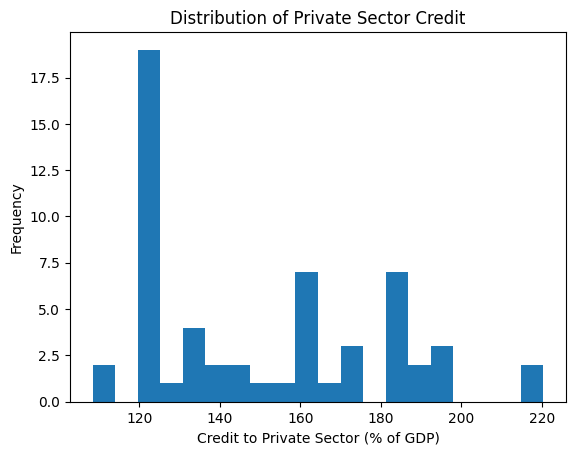

In [44]:
plt.hist(df_clean["credit_to_private_gdp"].dropna(), bins=20)
plt.xlabel("Credit to Private Sector (% of GDP)")
plt.ylabel("Frequency")
plt.title("Distribution of Private Sector Credit")
plt.show()

## 3.3 Time-Series Trends by Country

### 3.3.1 Lending interest rate over time

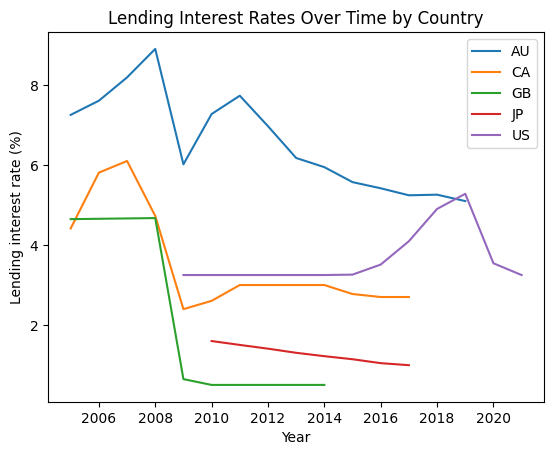

In [45]:
for code, group in df_clean.groupby("country_code"):
    plt.plot(group["year"], group["lending_interest_rate"], label=code)

plt.xlabel("Year")
plt.ylabel("Lending interest rate (%)")
plt.title("Lending Interest Rates Over Time by Country")
plt.legend()
plt.show()

### 3.3.2 Non-performing loans over time

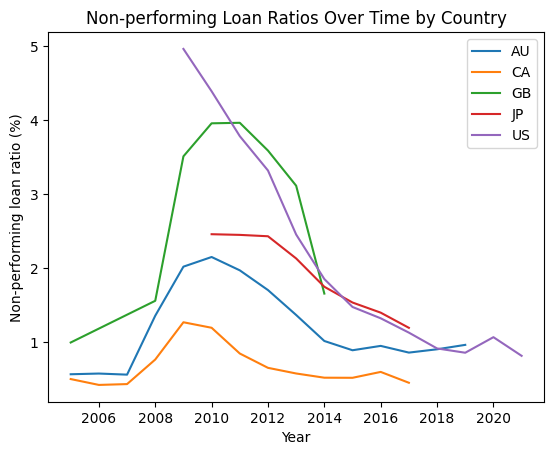

In [46]:
for code, group in df_clean.groupby("country_code"):
    plt.plot(group["year"], group["nonperforming_loan_ratio"], label=code)

plt.xlabel("Year")
plt.ylabel("Non-performing loan ratio (%)")
plt.title("Non-performing Loan Ratios Over Time by Country")
plt.legend()
plt.show()

## 3.4 Scatter Plots – Relationships Between Variables

### 3.4.1 Interest rate vs Non-performing loan ratio

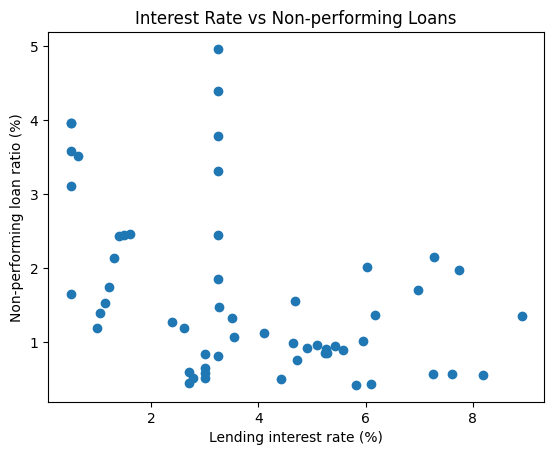

In [47]:
plt.scatter(df_clean["lending_interest_rate"], df_clean["nonperforming_loan_ratio"])
plt.xlabel("Lending interest rate (%)")
plt.ylabel("Non-performing loan ratio (%)")
plt.title("Interest Rate vs Non-performing Loans")
plt.show()

### 3.4.2 Credit-to-GDP vs Non-performing loans

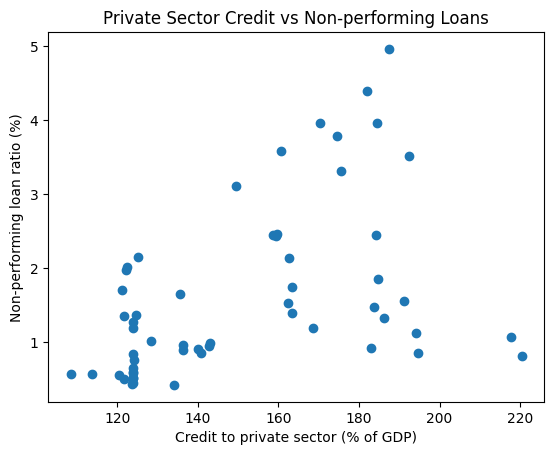

In [48]:
plt.scatter(df_clean["credit_to_private_gdp"], df_clean["nonperforming_loan_ratio"])
plt.xlabel("Credit to private sector (% of GDP)")
plt.ylabel("Non-performing loan ratio (%)")
plt.title("Private Sector Credit vs Non-performing Loans")
plt.show()

## 3.5 Country Comparison – Average Indicators Since 1990

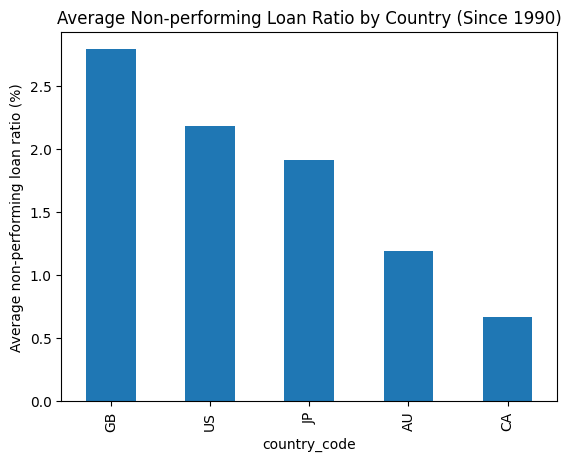

In [49]:
recent = df_clean[df_clean["year"] >= 1990]

avg_npl_by_country = (
    recent.groupby("country_code")["nonperforming_loan_ratio"]
    .mean()
    .sort_values(ascending=False)
)

avg_npl_by_country.plot(kind="bar")
plt.ylabel("Average non-performing loan ratio (%)")
plt.title("Average Non-performing Loan Ratio by Country (Since 1990)")
plt.show()

## 3.6 Additional Statistics – Sums and Ranges
In addition to the descriptive statistics generated earlier, I also compute the
sum of selected variables. Although summing macroeconomic indicators such as
interest rates is not meaningful, summing the credit-to-GDP values by country
gives an indication of which economies consistently allocate more credit to
the private sector over time.

In [50]:
df_clean.groupby("country_code")["credit_to_private_gdp"].sum().sort_values(ascending=False)

country_code
US    2468.352355
AU    1904.378923
CA    1617.754709
GB    1327.518016
JP    1298.185729
Name: credit_to_private_gdp, dtype: float64

## 3.7 Additional Exploration Using Boxplots
**Boxplots: Cross-Country Comparison of Key Loan Indicators**
In addition to histograms and scatter plots, boxplots provide a powerful way to visualise the spread, central tendency, and presence of outliers in numerical variables.
Because this dataset contains multiple countries observed over several decades, boxplots allow us to compare how lending interest rates, non-performing loan ratios, and credit-to-GDP levels vary across countries.

Boxplots help answer questions such as:

Which countries have historically higher or lower loan risk?

Which countries show the most stable lending environment?

Are there extreme values (outliers) associated with financial crises or structural changes?

How wide is the variability of each indicator within each economy?

By visualising the distribution for each country side by side, we obtain a clearer understanding of long-term structural differences in global credit conditions.

### 3.7.1 Boxplot – Distribution of Non-performing Loan Ratios by Country

<Figure size 1000x600 with 0 Axes>

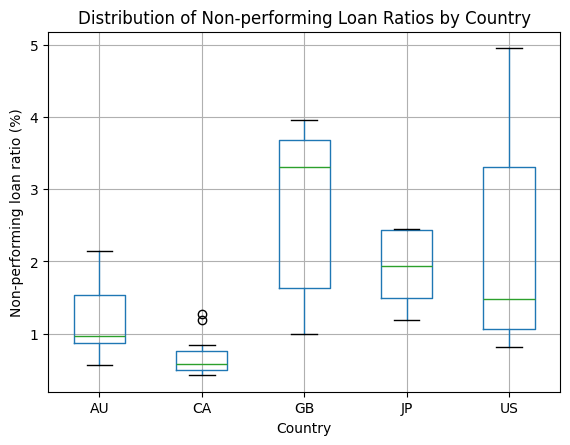

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
df_clean.boxplot(
    column="nonperforming_loan_ratio",
    by="country_code"
)
plt.title("Distribution of Non-performing Loan Ratios by Country")
plt.suptitle("")  # 去掉默认副标题
plt.xlabel("Country")
plt.ylabel("Non-performing loan ratio (%)")
plt.show()

### 3.7.2 Boxplot - Distribution of Lending Interest Rates by Country

<Figure size 1000x600 with 0 Axes>

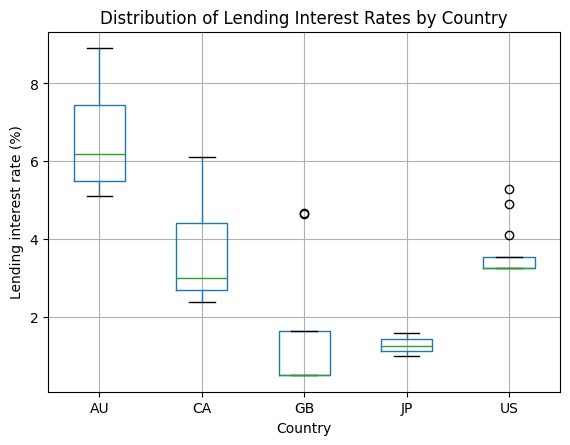

In [52]:
plt.figure(figsize=(10,6))
df_clean.boxplot(
    column="lending_interest_rate",
    by="country_code"
)
plt.title("Distribution of Lending Interest Rates by Country")
plt.suptitle("")
plt.xlabel("Country")
plt.ylabel("Lending interest rate (%)")
plt.show()

### 3.7.3 Boxplot – Distribution of Credit-to-GDP by Country

<Figure size 1000x600 with 0 Axes>

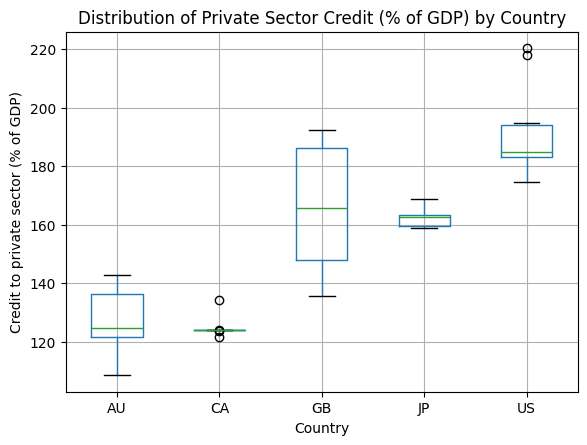

In [53]:
plt.figure(figsize=(10,6))
df_clean.boxplot(
    column="credit_to_private_gdp",
    by="country_code"
)
plt.title("Distribution of Private Sector Credit (% of GDP) by Country")
plt.suptitle("")
plt.xlabel("Country")
plt.ylabel("Credit to private sector (% of GDP)")
plt.show()

The boxplots reveal significant cross-country differences in the distribution of lending interest rates and non-performing loan ratios.
Countries such as the United States and the United Kingdom show a wider spread in interest rates, reflecting periods of monetary tightening during the 1980s and financial volatility in the 2000s.
Japan, on the other hand, exhibits consistently low and stable interest rates across decades.

For non-performing loans, higher medians and larger interquartile ranges in some economies indicate greater loan risk and variability.
Outliers in the boxplots correspond to known crisis years, which helps interpret sudden spikes in financial stress.

Overall, the boxplots complement the earlier histograms and scatter plots by summarising long-term distribution patterns across countries.